In [1]:
import pandas as pd
import numpy as np
import math

In [2]:
# For visualisations
import matplotlib.pyplot as plt
import seaborn as sns
subplots = plt.subplots

# Setting plotting parameters for consistent graphs
plt.rcParams.update({
    'figure.figsize': (8, 4),
    'figure.dpi': 240,

    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,

    'xtick.labelsize': 10,
    'ytick.labelsize': 10,

    'axes.spines.top': False,
    'axes.spines.right': False,

    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.8,

    'axes.axisbelow': True,

    'legend.frameon': False,

    'figure.constrained_layout.use': True,
})

In [3]:
RANDOM_STATE = 42

# Credit Risk Modelling

**Dataset**: [Give Me Some Credit (Kaggle)](https://www.kaggle.com/c/GiveMeSomeCredit)

In [4]:
data = pd.read_csv("../data/cs-training.csv", index_col=0)

In [5]:
x_var_list = [
    # Personal attributes
    'age',
    'NumberOfDependents',
    
    # Financial attributes
    'MonthlyIncome',
    'DebtRatio',
    'RevolvingUtilizationOfUnsecuredLines',
    
    # Credit history
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

y_var = 'SeriousDlqin2yrs'

### Pre-Processing decisions (after EDA)

1. Drop the single observation with age = 0.
2. Treat 98 in the delinquency variables as missing.
3. Impute missing values in MonthlyIncome and NumberOfDependents (using median values)
4. Test ln(1+x) transformations for highly skewed variables.
5. Standardise predictors for models that require it.
6. Preserve the original class imbalance.

In [6]:
x_vars_fit_for_transform = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

late_vars = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

## 3. Pre-processing

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression

In [8]:
# Copy the data so that the raw EDA dataset remains unchanged
model_data = data.copy()

### 3.1 Data Cleaning

In [9]:
# Remove the single clearly invalid age observation
model_data = model_data.loc[model_data['age'] >= 18].copy()

# Treat the special value 98 in the delinquency variables as missing
model_data[late_vars] = model_data[late_vars].replace(98, np.nan)

print(f"Observations after cleaning: {len(model_data):,}")

Observations after cleaning: 149,999


### 3.2 Test-train split

In [10]:
X = model_data[x_var_list].copy()
y = model_data[y_var].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y, # To preserve class-balance across train-test data split
    random_state=RANDOM_STATE
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("-" * 40)
print("Training default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Training observations: 119999
Test observations: 30000
----------------------------------------
Training default rate: 0.06684222368519738
Test default rate: 0.06683333333333333


### 3.3 Pipeline

Note that `MonthlyIncome` and `NumberOfDependents` have some missing values.  

Additionally, the `late_vars` all have value 98 for some columns, which we are treating as missing values. (We will revisit this later)

Missing values are imputed using the median calculated from the training data

In [11]:
# Log variables
log_vars = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

# Linear variables
linear_vars = [
    col for col in x_var_list
    if col not in log_vars
]

In [12]:
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_vars),
    ('linear', linear_pipeline, linear_vars)
])

## 4. Models

In [13]:
# Lots of mat-mul divide by 0, overflow etc. errors
# Math errors encountered during optimisation process
# Models are fitting fine, suppressing these errors for presentability...

import warnings

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="sklearn"
)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)


model_results = []
roc_curves = {}
cv_results = []

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [16]:
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):

    # -------------------------
    # Test-set performance
    # -------------------------
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_result = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    model_results.append(test_result)

    # -------------------------
    # ROC curve
    # -------------------------

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_curves[model_name] = {
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'auc': test_result['ROC-AUC']
    }

    # -------------------------
    # Cross-validation
    # -------------------------

    cv_auc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    cv_results.append({
        'Model': model_name,
        'CV ROC-AUC Mean': cv_auc.mean(),
        'CV ROC-AUC SD': cv_auc.std()
    })

    return test_result

### 4.1 Model training and evaluation

We run an ensemble of models:
1. **Dummy classifier**: Baseline, just predict the most frequent class across the dataset
2. **Logistic Regression**
3. **Linear Discriminant Analysis**
4. **Quadratic Discriminant Analysis**
5. **Decision Tree**
6. **Random Forest**

For each model, the preprocessing pipeline is:

1. Impute missing values using the median calculated from the training data.
2. Apply $\ln(1+x)$ to the selected highly skewed variables.
3. Standardise all predictors.

All preprocessing is performed within the pipeline to avoid using information from the validation or test data.

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis


models = {
    'Dummy Classifier': DummyClassifier(
        strategy='most_frequent'
    ),

    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),
    
    'LDA' : Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LinearDiscriminantAnalysis())
    ]),

    'QDA' : Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', QuadraticDiscriminantAnalysis())
    ]),

    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

In [18]:
# Reset the results before training and fitting again!
model_results = []
roc_curves = {}
cv_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    evaluate_model(
        model_name=name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

In [19]:
results_df = pd.DataFrame(model_results).round(3)

display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Classifier,0.933,0.000,0.000,0.000,0.500
1,Logistic Regression,0.935,0.542,0.163,0.250,0.839
2,LDA,0.928,0.446,0.324,0.375,0.851
3,QDA,0.896,0.326,0.529,0.404,0.830
4,Decision Tree,0.898,0.256,0.275,0.265,0.610
5,Random Forest,0.934,0.523,0.179,0.266,0.849


In [20]:
cv_results_df = pd.DataFrame(cv_results).round(3)

display(cv_results_df)

,Model,CV ROC-AUC Mean,CV ROC-AUC SD
0,Dummy Classifier,0.500,0.000
1,Logistic Regression,0.833,0.007
2,LDA,0.846,0.007
3,QDA,0.829,0.005
4,Decision Tree,0.610,0.007
5,Random Forest,0.840,0.004


#### 4.1.1 Logistic Regression Interpretation

Logistic regression provides an **interpretable benchmark** for the prediction exercise.  

Because the predictors are standardised within the preprocessing pipeline, the estimated
coefficients measure **the change in log-odds** associated with a one-standard-deviation
increase in the corresponding transformed predictor, holding the other predictors fixed.

##### 4.1.1.a Logistic Regression: Coefficients

In [21]:
logit_model = models['Logistic Regression']

logit_preprocessor = logit_model.named_steps['preprocessor']
logit_classifier = logit_model.named_steps['classifier']

feature_names = logit_preprocessor.get_feature_names_out()
feature_names = [
    name.replace('log__', 'log1p_')
        .replace('linear__', '')
    for name in feature_names
]

coefficients = logit_classifier.coef_[0]

logit_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

logit_coefficients['Odds Change (%)'] = (
    (logit_coefficients['Odds Ratio'] - 1) * 100
)

logit_coefficients['Abs Coefficient'] = (
    logit_coefficients['Coefficient'].abs()
)

logit_coefficients = (
    logit_coefficients
    .sort_values('Abs Coefficient', ascending=False)
    .drop(columns='Abs Coefficient')
)

display(logit_coefficients.round(3))

,Feature,Coefficient,Odds Ratio,Odds Change (%)
1,log1p_NumberOfTime30-59DaysPastDueNotWorse,0.413,1.511,51.096
3,log1p_NumberOfTimes90DaysLate,0.402,1.494,49.426
4,age,-0.368,0.692,-30.755
6,MonthlyIncome,-0.290,0.748,-25.186
2,log1p_NumberOfTime60-89DaysPastDueNotWorse,0.235,1.265,26.540
0,log1p_RevolvingUtilizationOfUnsecuredLines,0.198,1.219,21.934
7,DebtRatio,-0.112,0.894,-10.598
9,NumberRealEstateLoansOrLines,0.107,1.113,11.297
5,NumberOfDependents,0.047,1.048,4.777
8,NumberOfOpenCreditLinesAndLoans,0.011,1.011,1.060


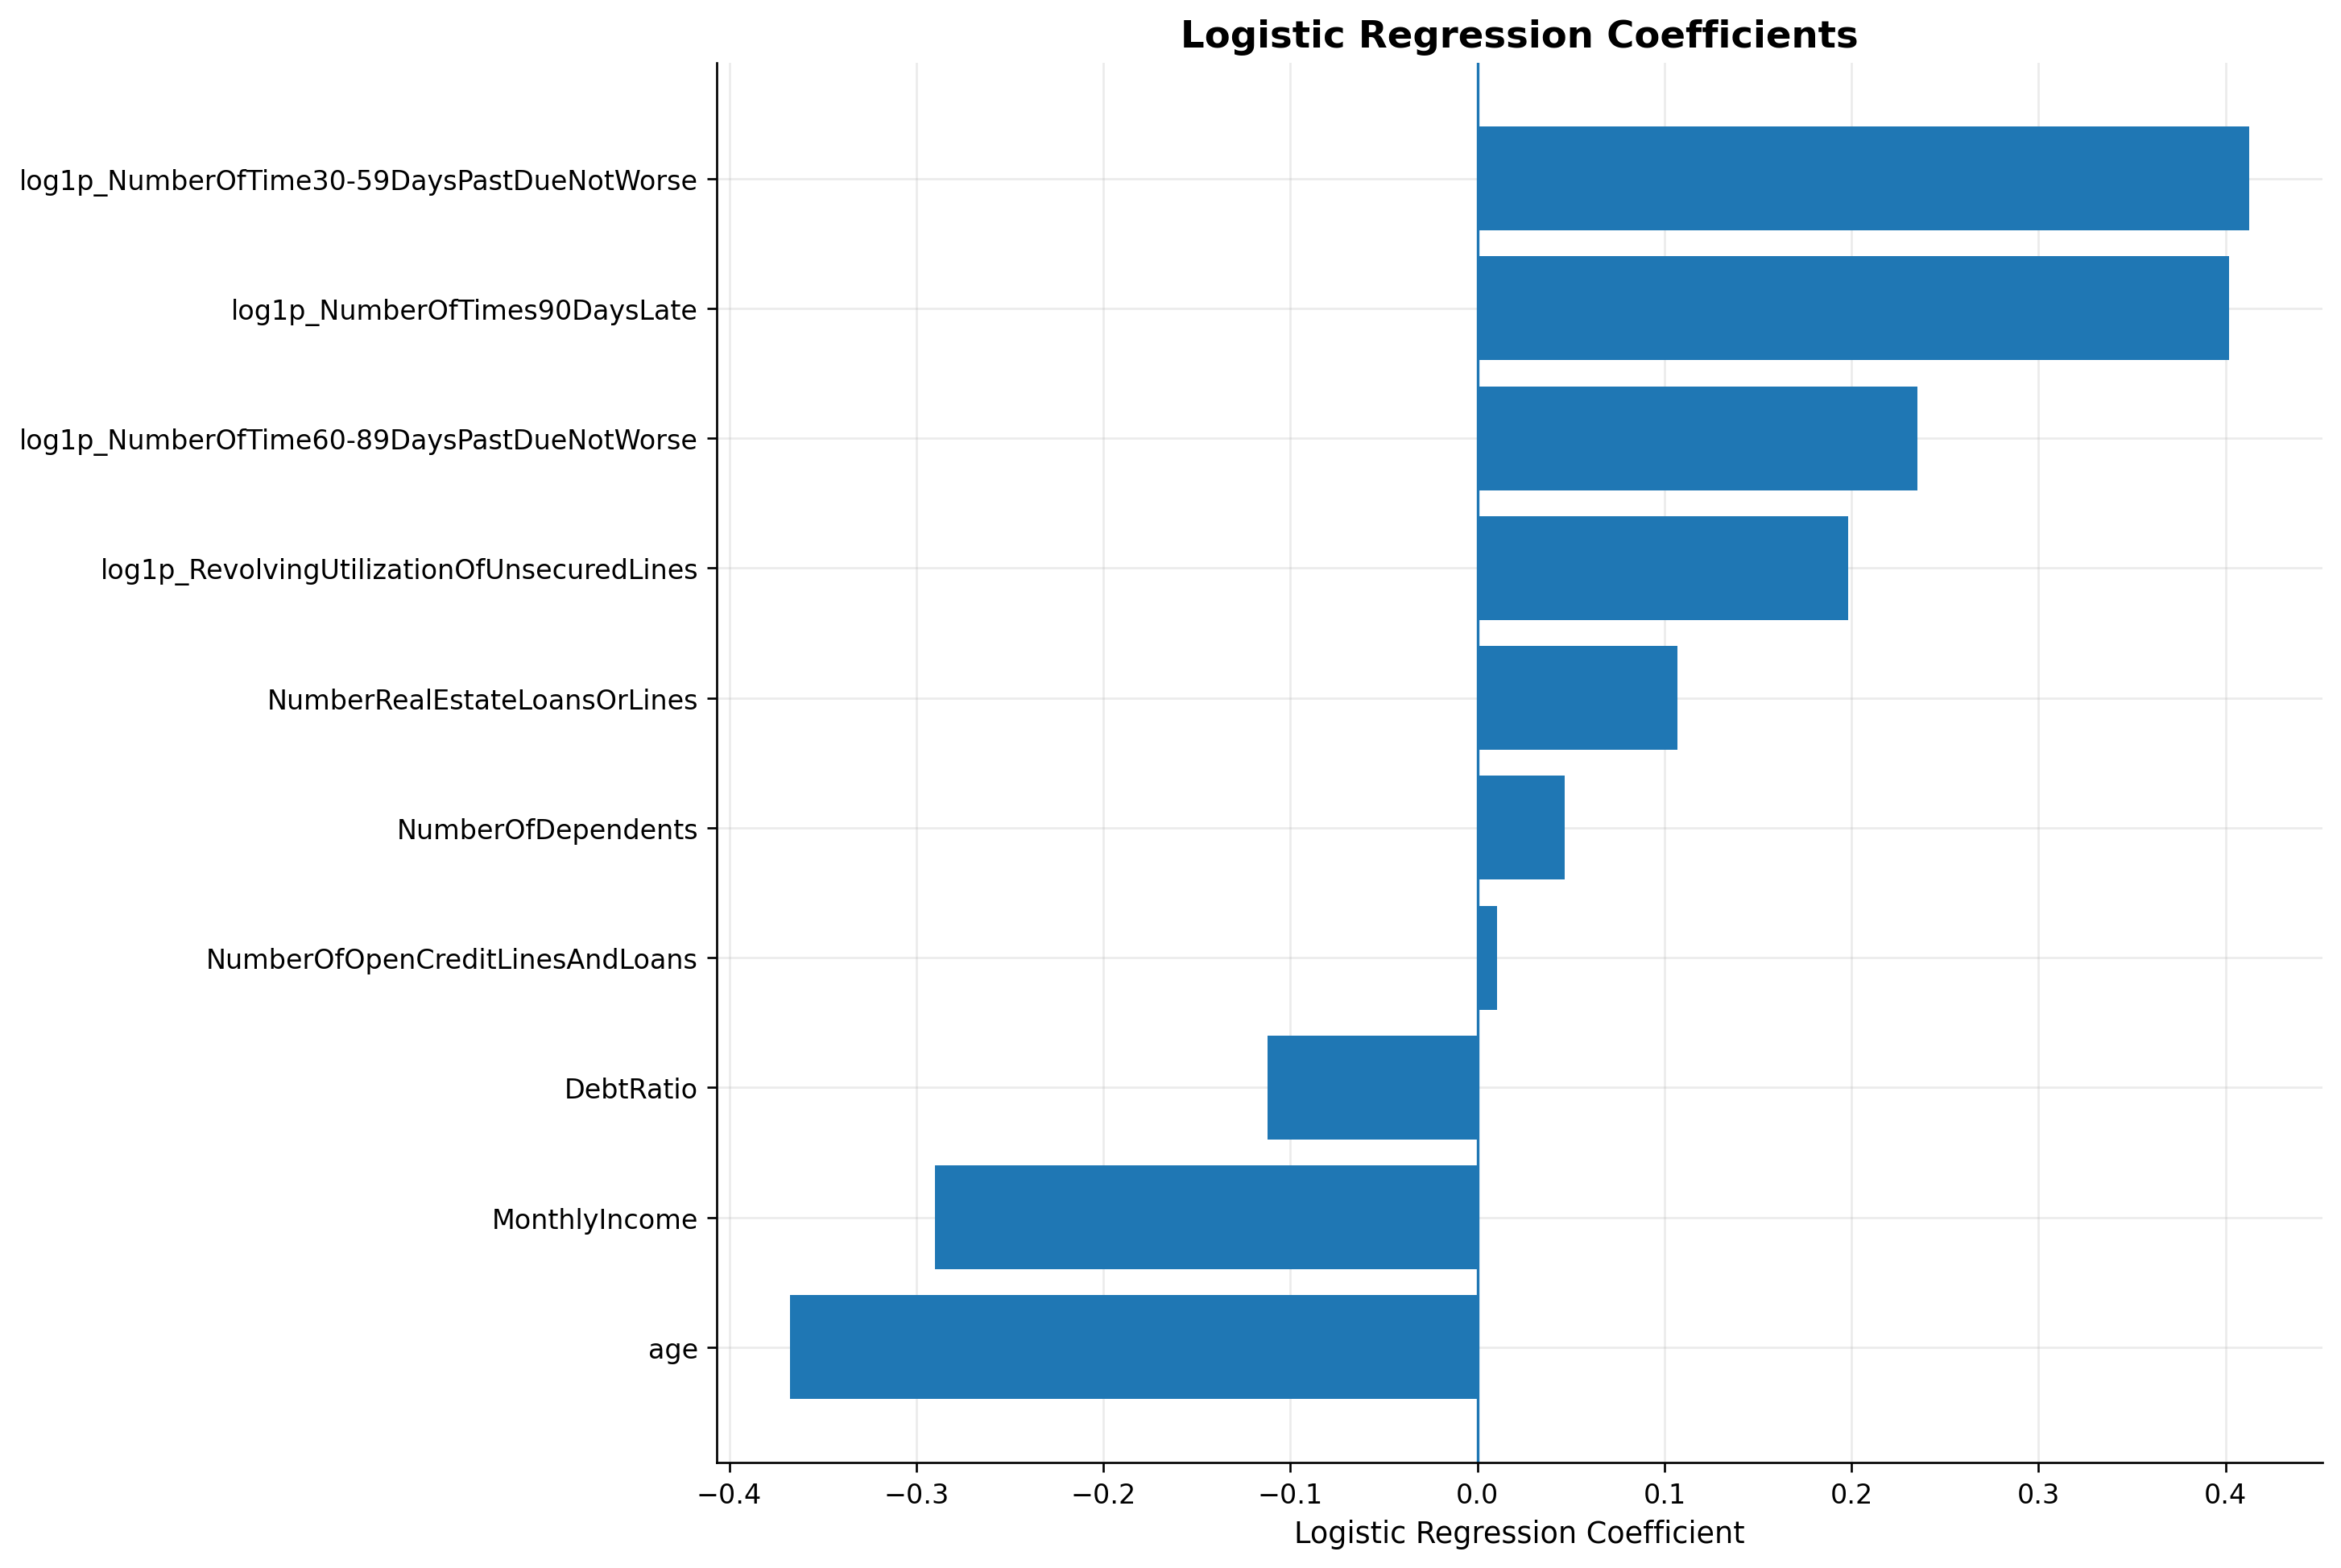

In [22]:
plot_data = logit_coefficients.sort_values('Coefficient')

plt.figure(figsize=(12, 8))

plt.barh(
    plot_data['Feature'],
    plot_data['Coefficient']
)

plt.axvline(0, linewidth=1)

plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('')
plt.title('Logistic Regression Coefficients')

plt.show()

#### 4.1.1.b Logistic Regression: Interpretation

Previous delinquency is the strongest positive predictor in the logistic model. A one-standard-deviation increase in the transformed 30–59, 60–89, and 90+ days-past-due variables is associated with approximately 51%, 27%, and 49% higher odds of serious delinquency, respectively.

`Age` and `MonthlyIncome` have the strongest negative associations, with one-standard-deviation increases associated with approximately 31% and 25% lower odds. Revolving credit utilisation is also positively associated with delinquency.

Overall, **past repayment behaviour appears to be more informative for predicting future delinquency than most demographic and credit-profile variables.**

*These are predictive associations, not causal effects.*

#### 4.1.2 Random Forest Interpretation

Random Forests provide a complementary view of predictor importance. 
Unlike the logistic regression coefficients, which describe the direction and 
magnitude of a linear association, Random Forest feature importance measures 
the contribution of each predictor to reducing impurity across the trees in 
the ensemble.

##### 4.1.2.a Random Forest: Feature Importance

In [23]:
rf_model = models['Random Forest']

rf_preprocessor = rf_model.named_steps['preprocessor']
rf_classifier = rf_model.named_steps['classifier']

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

rf_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

rf_importances['Feature'] = [
    name.replace('log__', 'log1p_')
        .replace('linear__', '')
    for name in rf_importances['Feature']
]

rf_importances = (
    rf_importances
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

display(rf_importances.round(3))

,Feature,Importance
0,log1p_RevolvingUtilizationOfUnsecuredLines,0.195
1,DebtRatio,0.180
2,MonthlyIncome,0.148
3,age,0.129
4,NumberOfOpenCreditLinesAndLoans,0.092
5,log1p_NumberOfTimes90DaysLate,0.087
6,log1p_NumberOfTime30-59DaysPastDueNotWorse,0.049
7,log1p_NumberOfTime60-89DaysPastDueNotWorse,0.046
8,NumberOfDependents,0.042
9,NumberRealEstateLoansOrLines,0.034


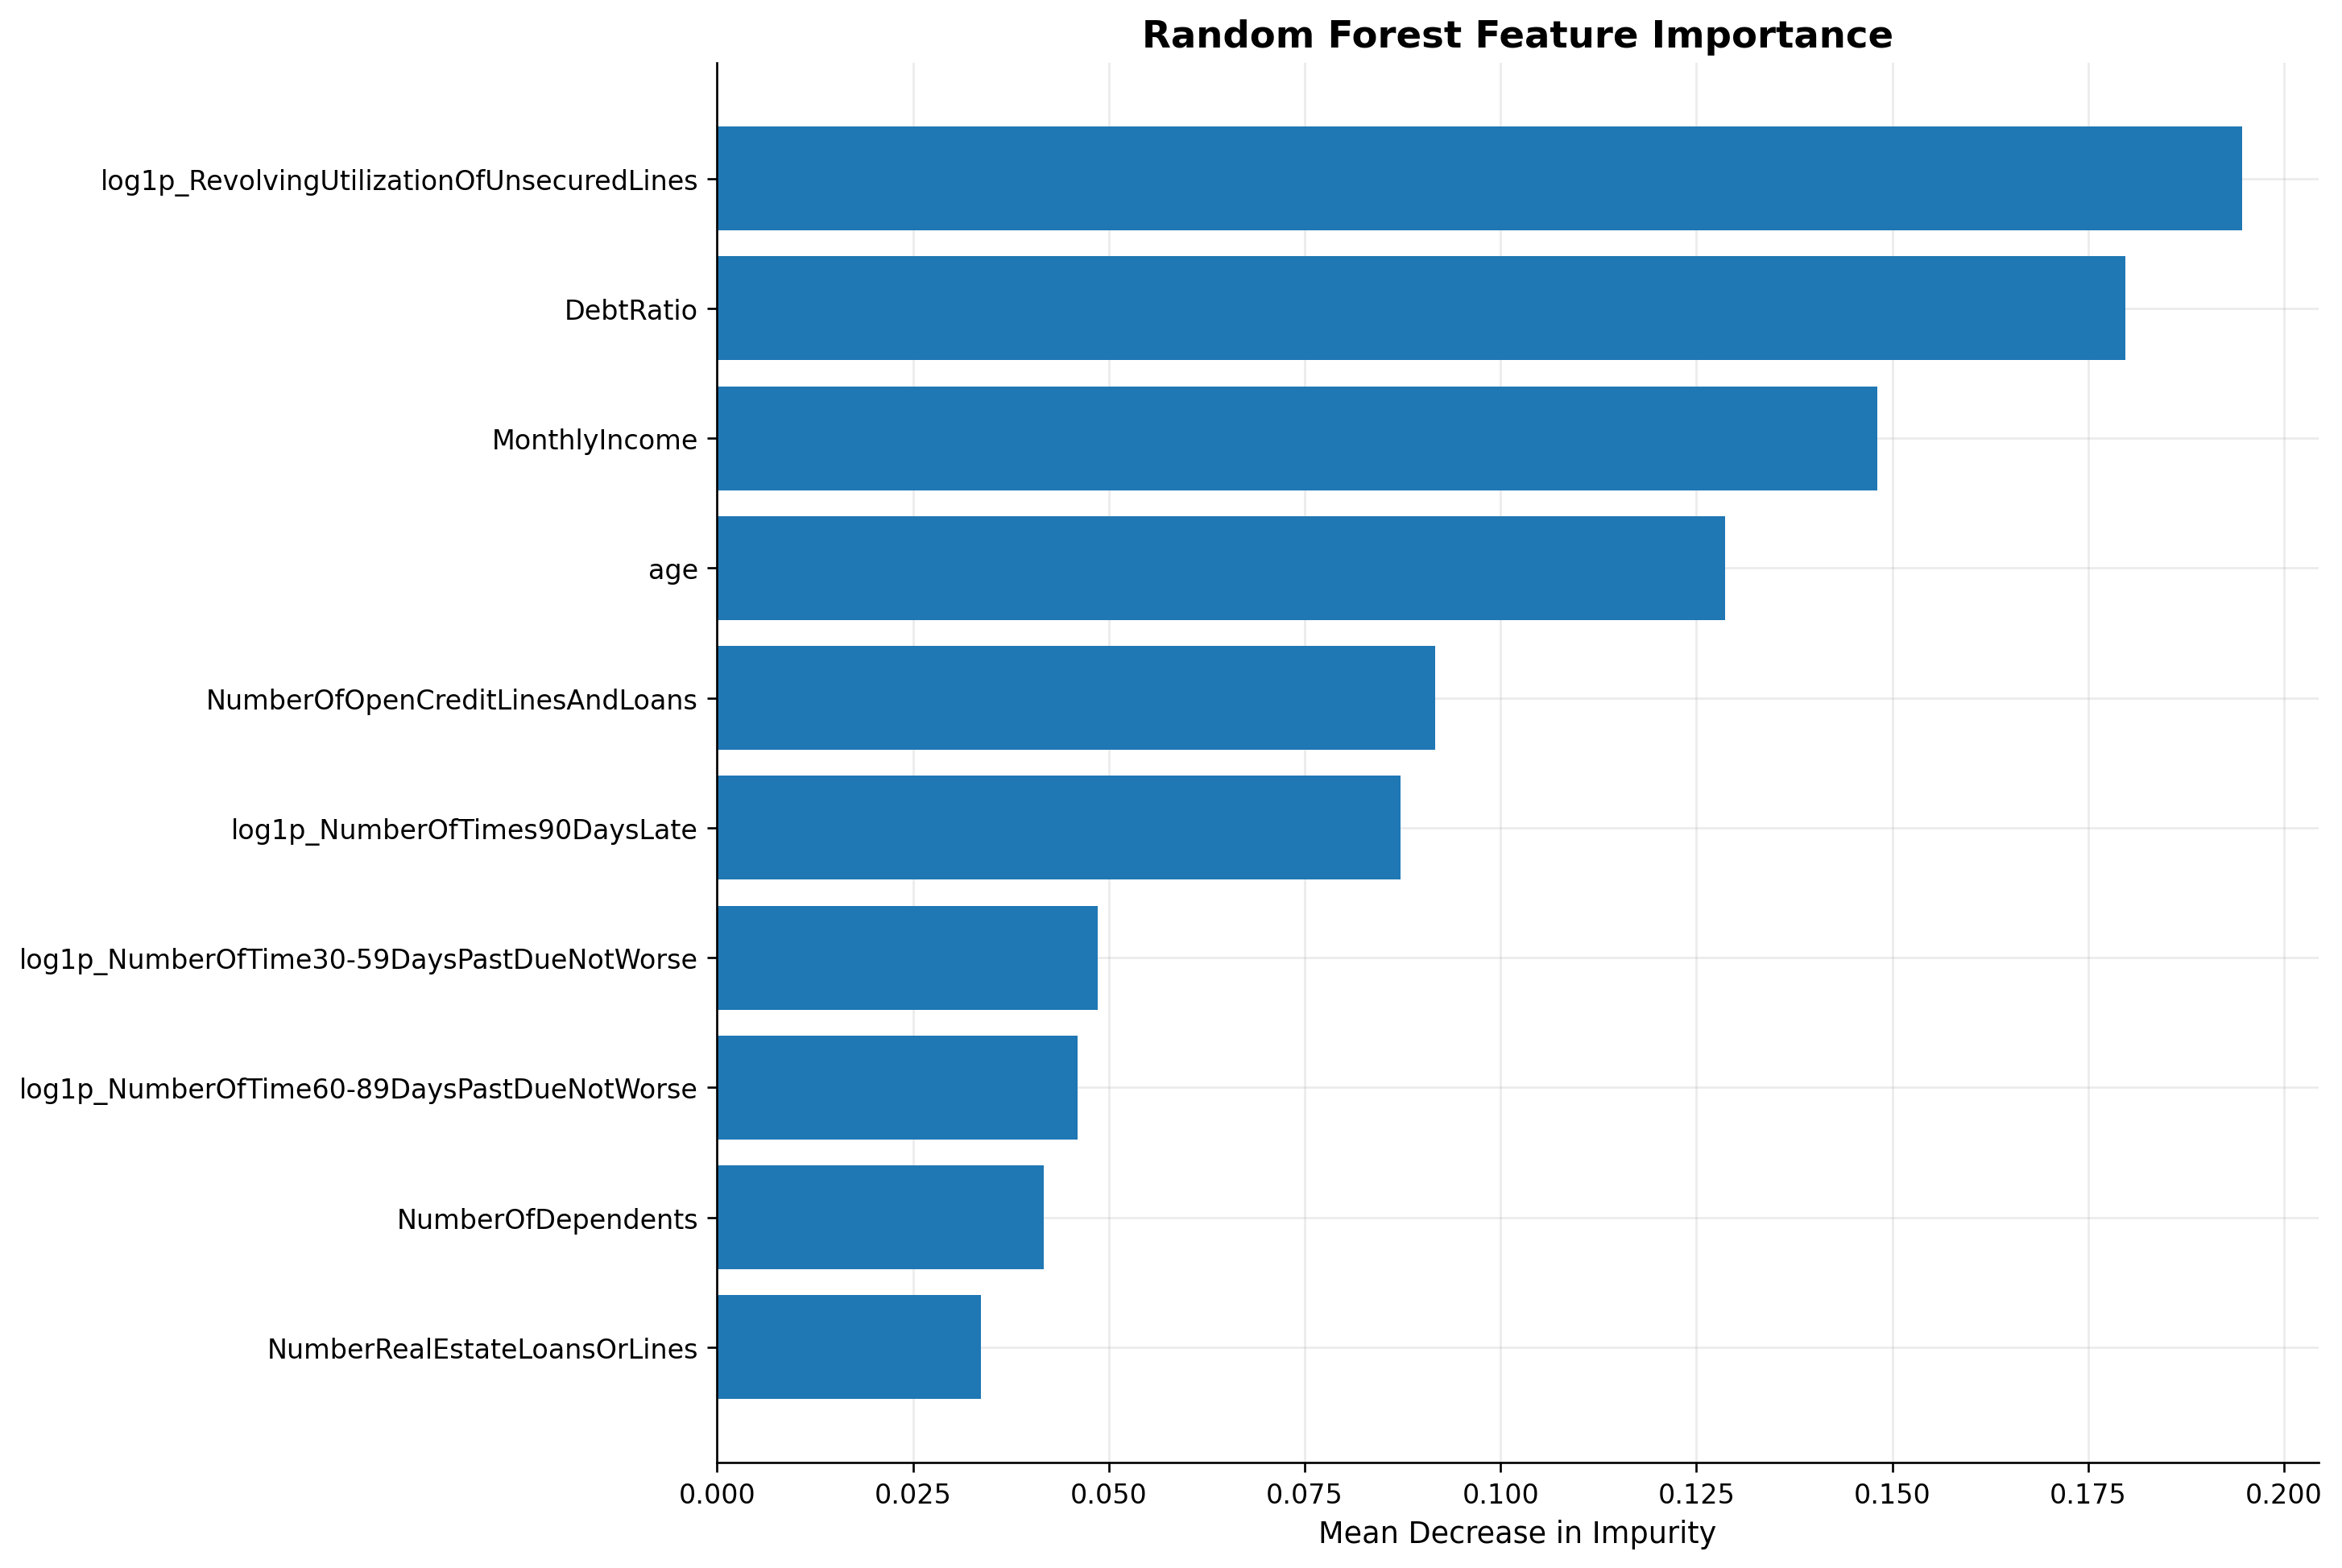

In [24]:
plot_data = rf_importances.sort_values('Importance')

plt.figure(figsize=(12, 8))

plt.barh(
    plot_data['Feature'],
    plot_data['Importance']
)

plt.xlabel('Mean Decrease in Impurity')
plt.ylabel('')
plt.title('Random Forest Feature Importance')

plt.show()

##### 4.1.2.b Random Forest: Interpretation

Random Forests provide a different view of predictor importance from logistic regression.

The delinquency variables are less prominent in the Random Forest than in logistic regression, while NumberOfOpenCreditLinesAndLoans is more important. This suggests that the models are using the predictors differently

Feature importance measures predictive usefulness within this model; it should not be interpreted as a causal effect

### 4.2 ROC Curves, Precision-Recall Analysis, Threshold Analysis

##### Why ROC-AUC and thresholds matter

The model produces a probability of serious delinquency rather than a simple yes/no prediction. To turn these probabilities into decisions, we need to choose a threshold.

This creates a **trade-off**:
- A low threshold will flag more borrowers and catch more delinquent borrowers, but will also generate more false alarms.
- A high threshold will produce fewer flags, but may miss more delinquent borrowers.

This matters in practice because **a delinquency flag is not costless**. If every borrower is flagged, we achieve 100% recall, but precision falls to the delinquency rate: most flagged borrowers would be false positives. These flagged borrowers may then be rejected for credit, or sent for manual review, quickly making the system impractical.

ROC-AUC evaluates how well a model ranks borrowers by risk across all possible thresholds, while precision and recall help us choose an appropriate operating point for the eventual business use case.

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

#### 4.2.1 ROC curves

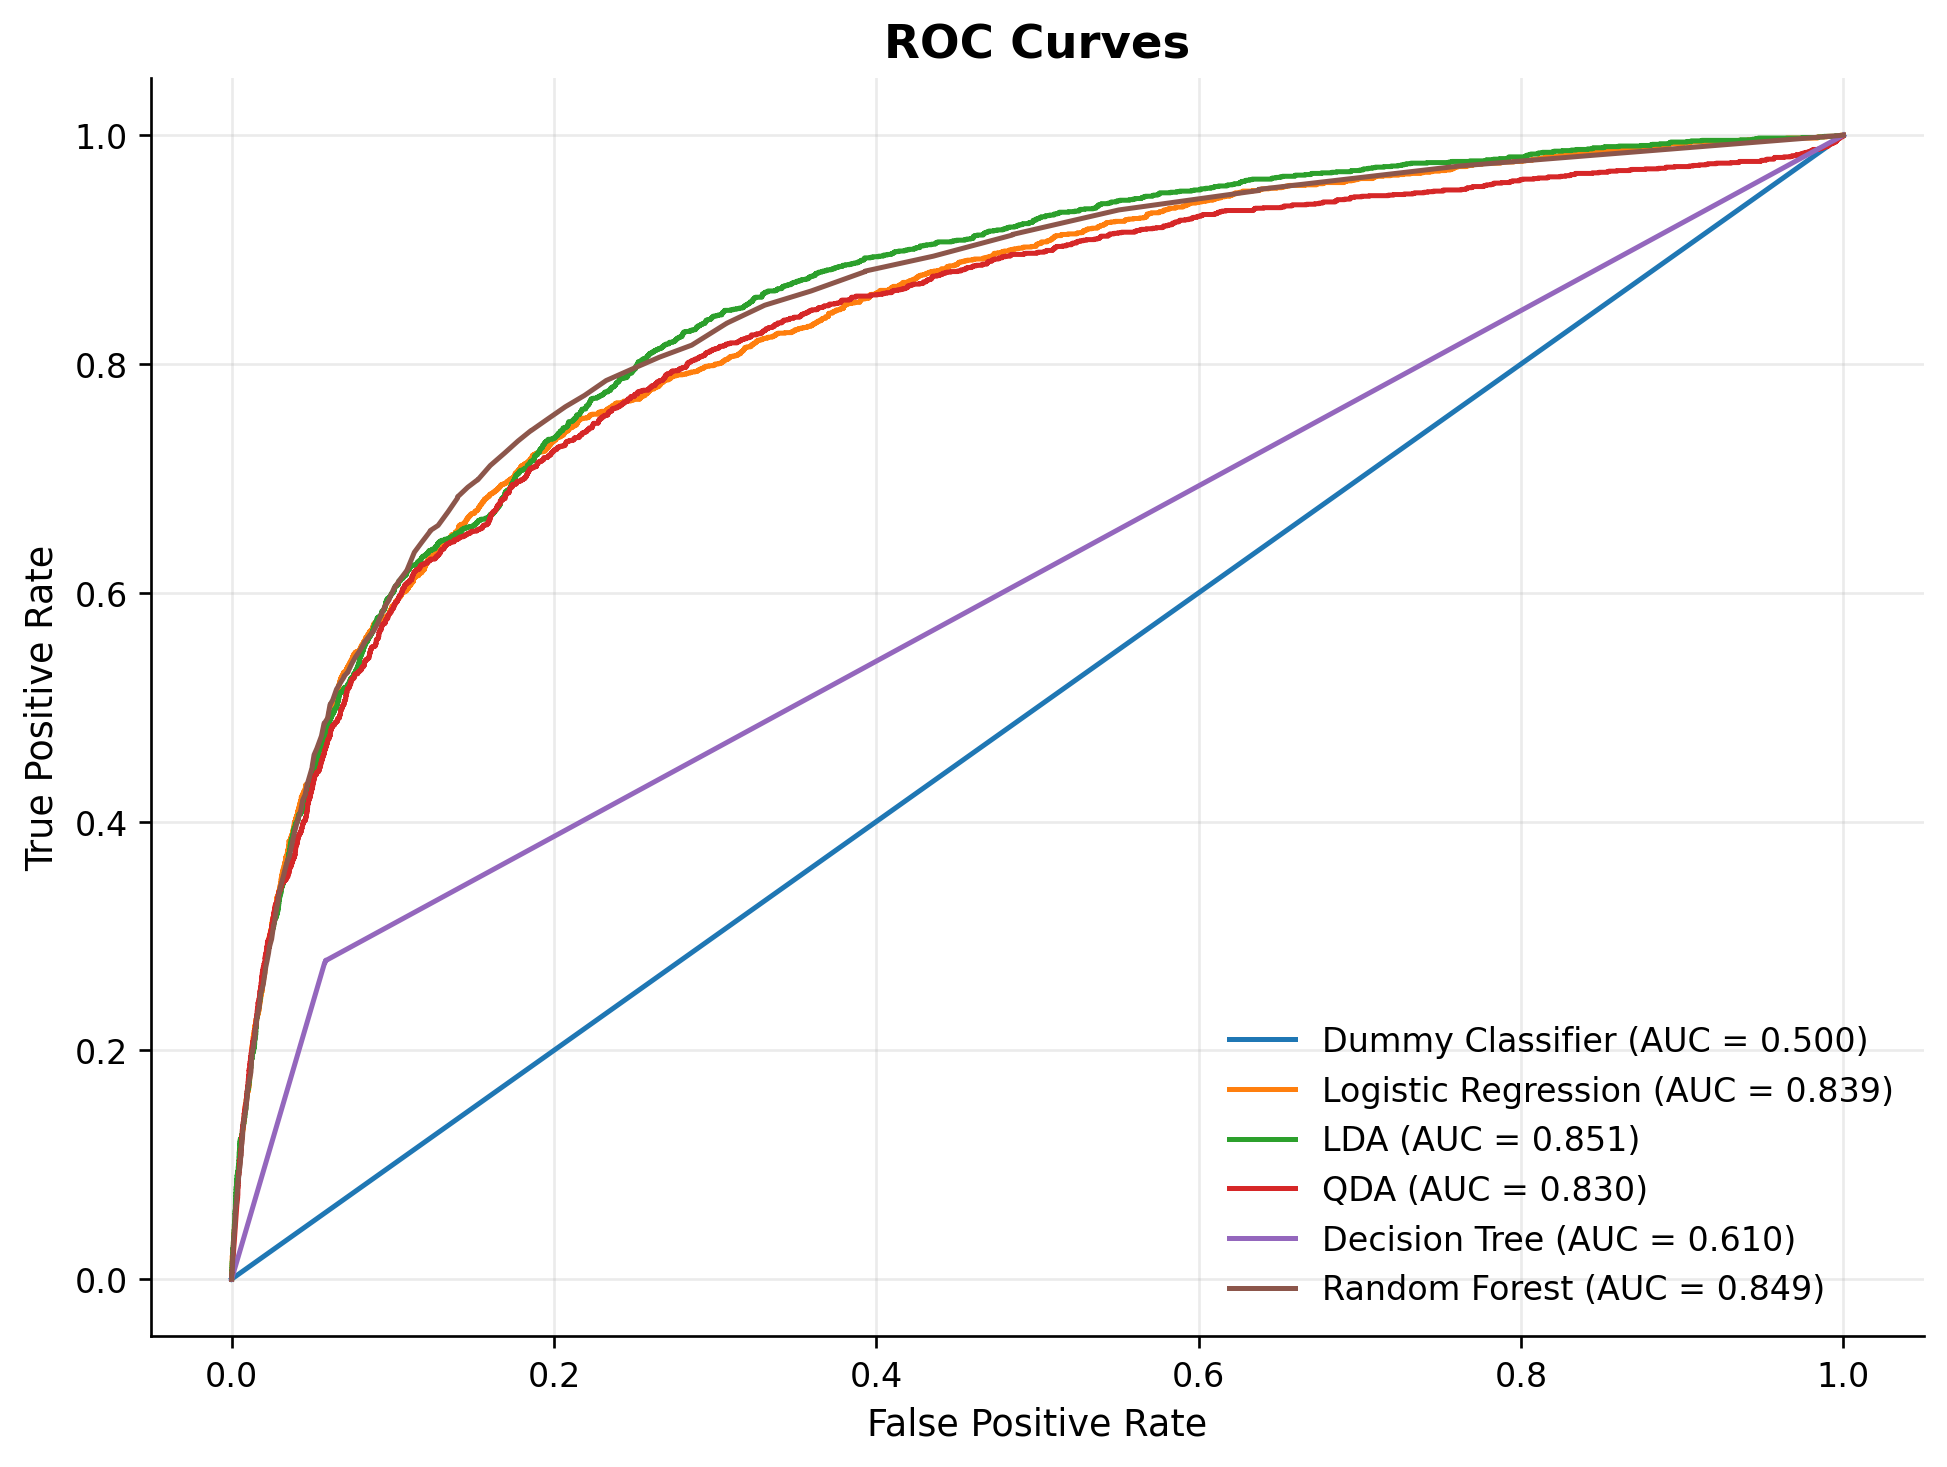

In [26]:
plt.figure(figsize=(8, 6))

for model_name, roc_data in roc_curves.items():
    plt.plot(
        roc_data['fpr'],
        roc_data['tpr'],
        label=f"{model_name} (AUC = {roc_data['auc']:.3f})"
    )

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

LDA performs best on ROC-AUC (0.851 on the test set; 0.846 in cross-validation), followed closely by Random Forest (0.849; 0.840) and Logistic Regression (0.839; 0.833). **The small differences suggest that the more complex Random Forest does not provide a large improvement over the simpler models.**

In [27]:
# Recall
cv_results_df

,Model,CV ROC-AUC Mean,CV ROC-AUC SD
0,Dummy Classifier,0.500,0.000
1,Logistic Regression,0.833,0.007
2,LDA,0.846,0.007
3,QDA,0.829,0.005
4,Decision Tree,0.610,0.007
5,Random Forest,0.840,0.004


#### 4.2.2 Precision-Recall Curves

Precision-recall is particularly useful here because serious delinquency is relatively rare. It focuses on the trade-off between identifying delinquent borrowers and generating false positives.

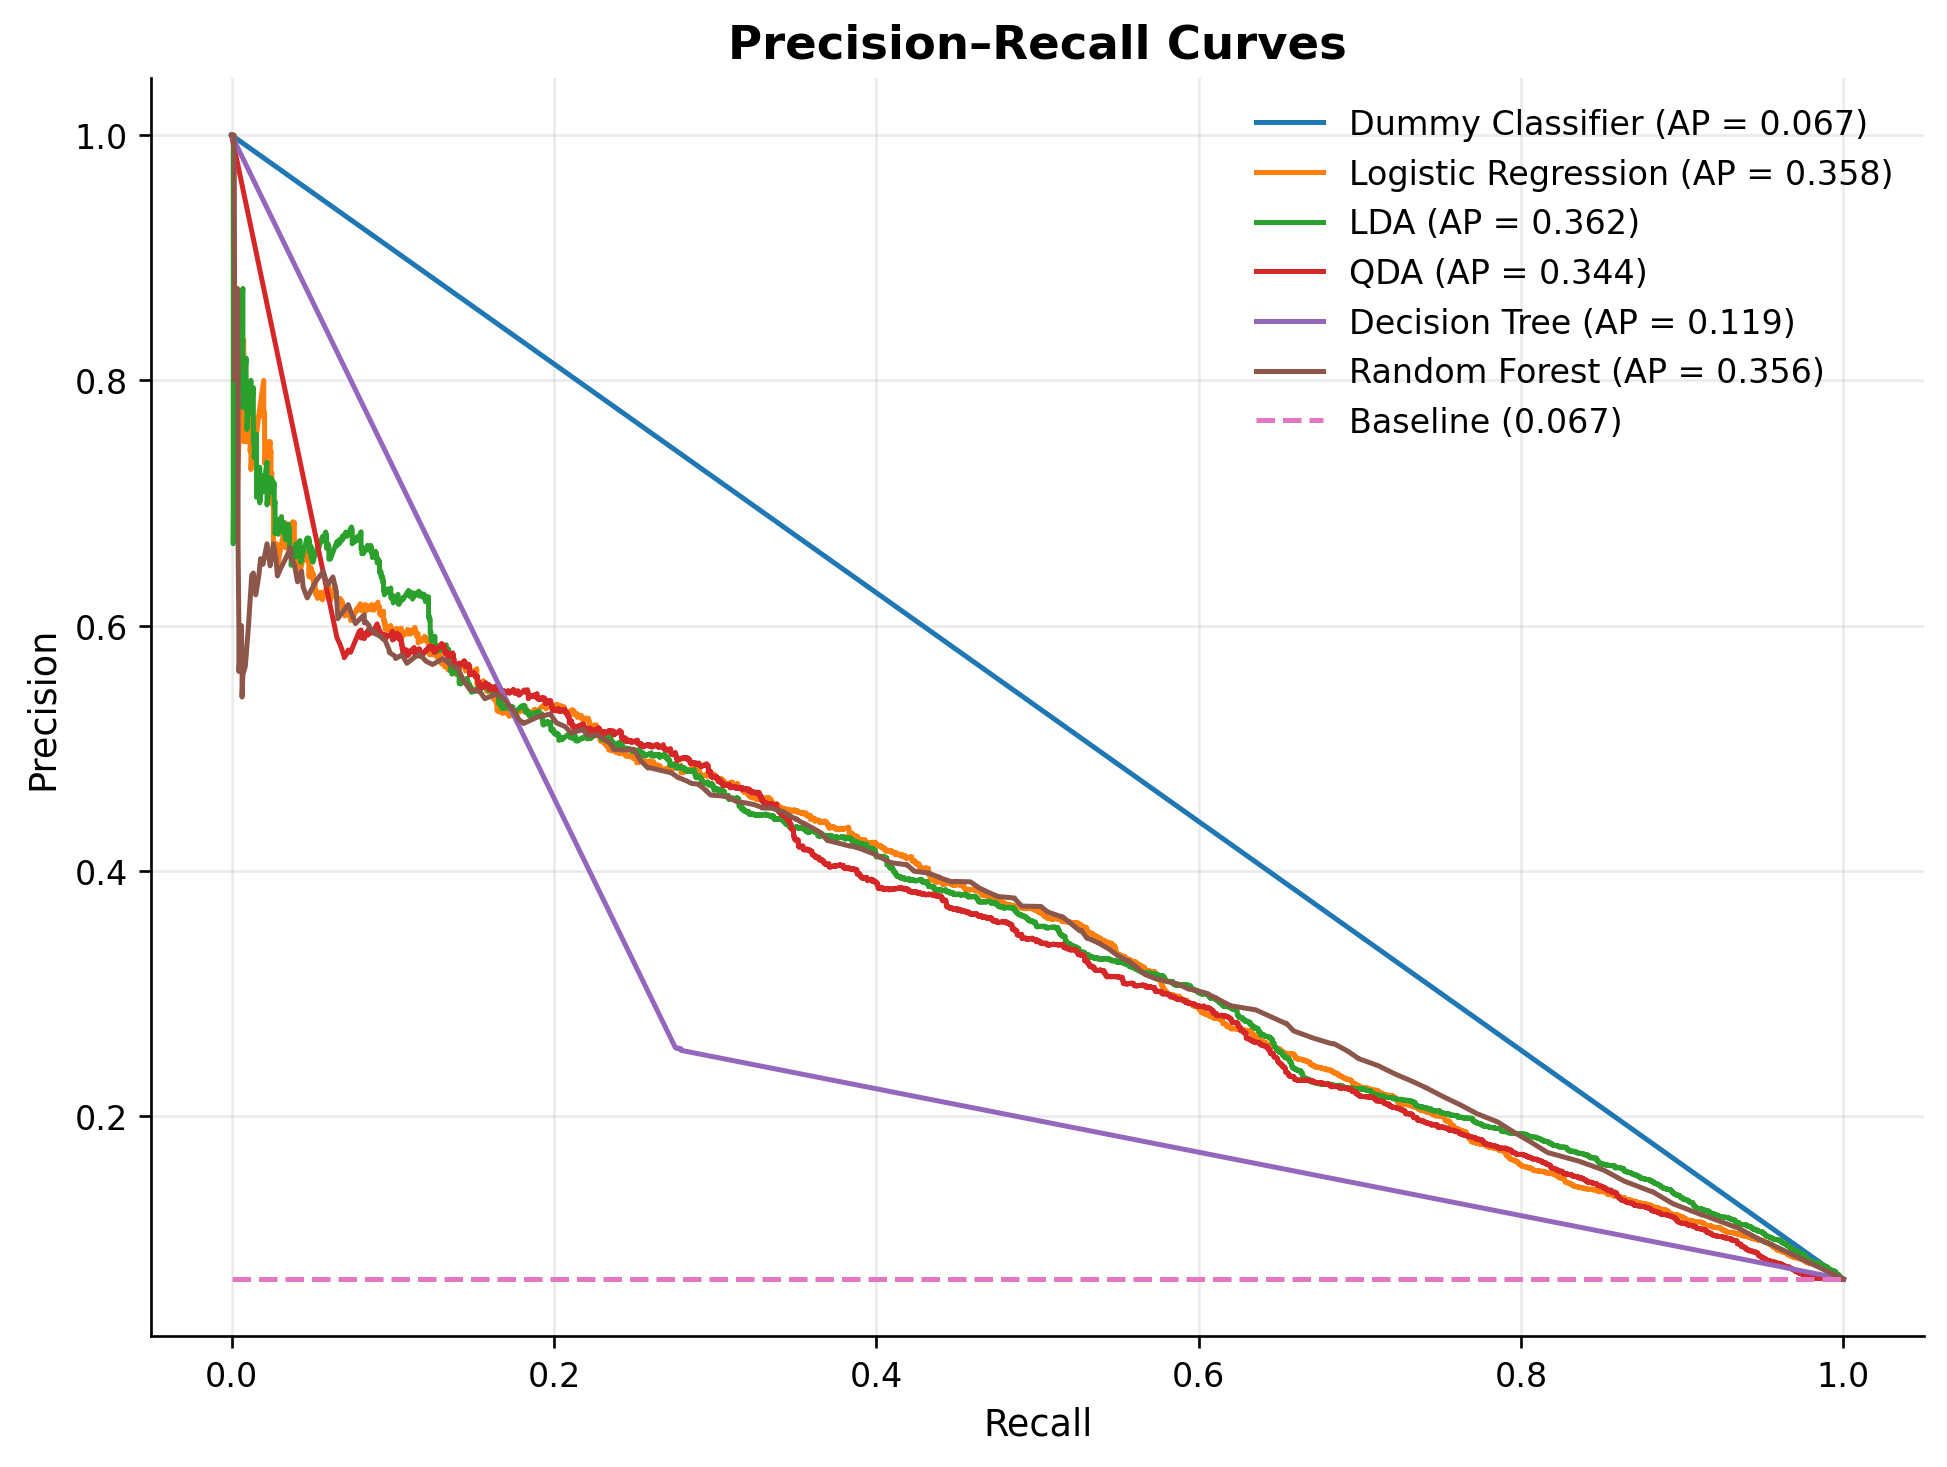

In [28]:
plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {ap:.3f})"
    )

# Baseline = prevalence of positive class
baseline = y_test.mean()

sns.lineplot(
    x=[0, 1],
    y=[baseline, baseline],
    linestyle='--',
    label=f'Baseline ({baseline:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curves')
plt.legend()
plt.show()

In [29]:
pr_results = []

for model_name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    ap = average_precision_score(
        y_test,
        y_prob
    )

    pr_results.append({
        'Model': model_name,
        'Average Precision': ap
    })

pr_results_df = (
    pd.DataFrame(pr_results)
    .sort_values('Average Precision', ascending=False)
    .round(3)
)

display(pr_results_df)

print(f"Positive-class prevalence: {y_test.mean():.3f}")

,Model,Average Precision
2,LDA,0.362
1,Logistic Regression,0.358
5,Random Forest,0.356
3,QDA,0.344
4,Decision Tree,0.119
0,Dummy Classifier,0.067


Positive-class prevalence: 0.067


LDA again performs best, with Average Precision of 0.362, followed by Logistic Regression (0.358) and Random Forest (0.356). The differences are small, so there is little evidence that one of these three models is clearly superior on predictive performance alone.

The Decision Tree performs substantially worse, with Average Precision of 0.119.

#### 4.2.3 Threshold Analysis

Classification thresholds determine how predicted probabilities are converted into binary decisions. Because the positive class is relatively rare, the default threshold of 0.5 may not provide a useful balance between precision and recall. 

Thresholds are selected using out-of-fold training predictions and then applied once to the held-out test set.

##### 4.2.3.a Precision, Recall, F1 across Thresholds

In [30]:
thresholds = np.arange(0.01, 0.51, 0.01)

In [31]:
threshold_results = []
threshold_models = {
    name: model
    for name, model in models.items()
    if name in ['Logistic Regression', 'LDA', 'QDA', 'Random Forest']
}

for model_name, model in threshold_models.items():

    # Generate out-of-fold probabilities using training data only
    y_prob = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        threshold_results.append({
            'Model': model_name,
            'Threshold': threshold,
            'Precision': precision_score(
                y_train,
                y_pred,
                zero_division=0
            ),
            'Recall': recall_score(
                y_train,
                y_pred,
                zero_division=0
            ),
            'F1': f1_score(
                y_train,
                y_pred,
                zero_division=0
            )
        })

threshold_results_df = pd.DataFrame(threshold_results)

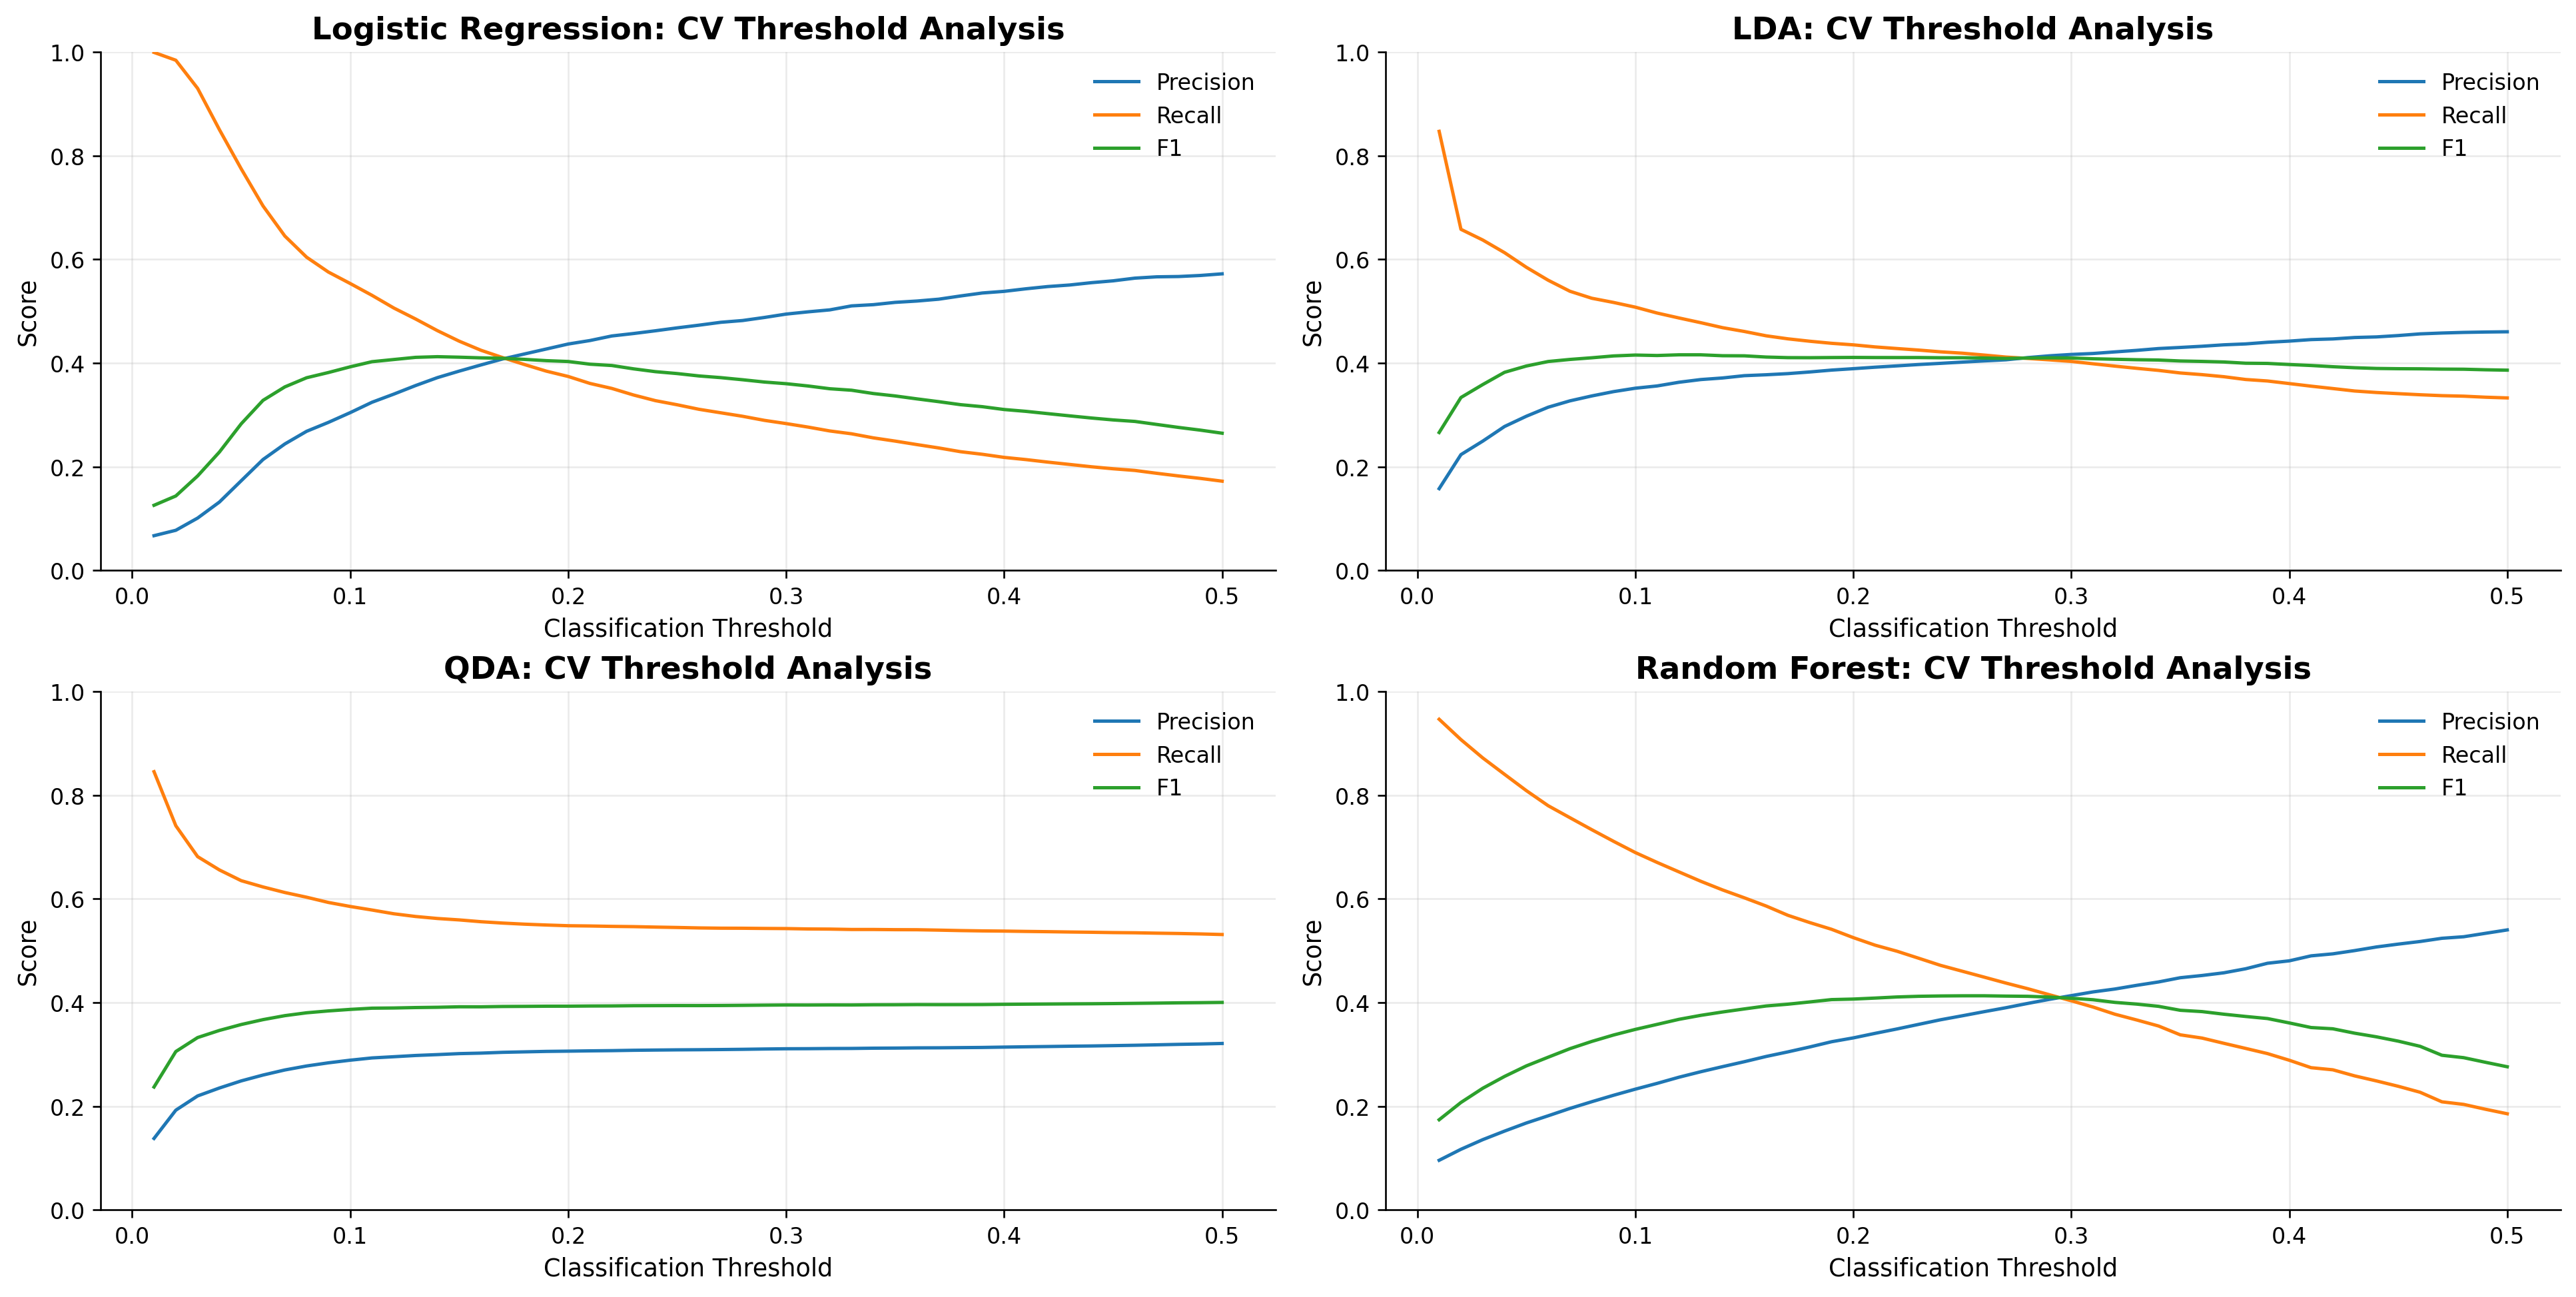

In [32]:
fig, axes = subplots(nrows=2, ncols=2, figsize=(16,8))
axes = axes.flatten()

for idx, model_name in enumerate(threshold_models.keys()):

    plot_data = threshold_results_df[
        threshold_results_df['Model'] == model_name
    ]

    t_ax = axes[idx]

    sns.lineplot(
        data=plot_data,
        x='Threshold',
        y='Precision',
        label='Precision',
        ax = t_ax
    )

    sns.lineplot(
        data=plot_data,
        x='Threshold',
        y='Recall',
        label='Recall',
        ax = t_ax
    )

    sns.lineplot(
        data=plot_data,
        x='Threshold',
        y='F1',
        label='F1',
        ax = t_ax
    )

    t_ax.set_xlabel('Classification Threshold')
    t_ax.set_ylabel('Score')
    t_ax.set_title(f'{model_name}: CV Threshold Analysis')
    t_ax.set_ylim(0, 1)
    t_ax.legend()


# Remove unused subplots
for j in range(len(threshold_models), len(axes)):
    fig.delaxes(axes[j])

plt.show();

The operating threshold is selected by maximising F1 on the out-of-fold predictions generated from the training data. We use F1 to choose a threshold because we do not have an explicit business cost for false positives versus false negatives.

In [33]:
threshold_selection_df = (
    threshold_results_df
    .loc[
        threshold_results_df
        .groupby('Model')['F1']
        .idxmax()
    ]
    .rename(columns={
        'Threshold': 'Selected Threshold',
        'Precision': 'OOF Precision',
        'Recall': 'OOF Recall',
        'F1': 'OOF F1'
    })
    .sort_values('OOF F1', ascending=False)
    .reset_index(drop=True)
    .round(3)
)

display(threshold_selection_df)

,Model,Selected Threshold,OOF Precision,OOF Recall,OOF F1
0,LDA,0.12,0.363,0.487,0.416
1,Random Forest,0.26,0.382,0.449,0.413
2,Logistic Regression,0.14,0.372,0.463,0.412
3,QDA,0.50,0.321,0.531,0.400


The selected threshold is then treated as fixed and applied to the untouched
test set. The resulting precision, recall, and F1 scores therefore represent
out-of-sample performance at an operating point determined without using the
test outcomes.

##### 4.2.3.b F1-selected thresholds

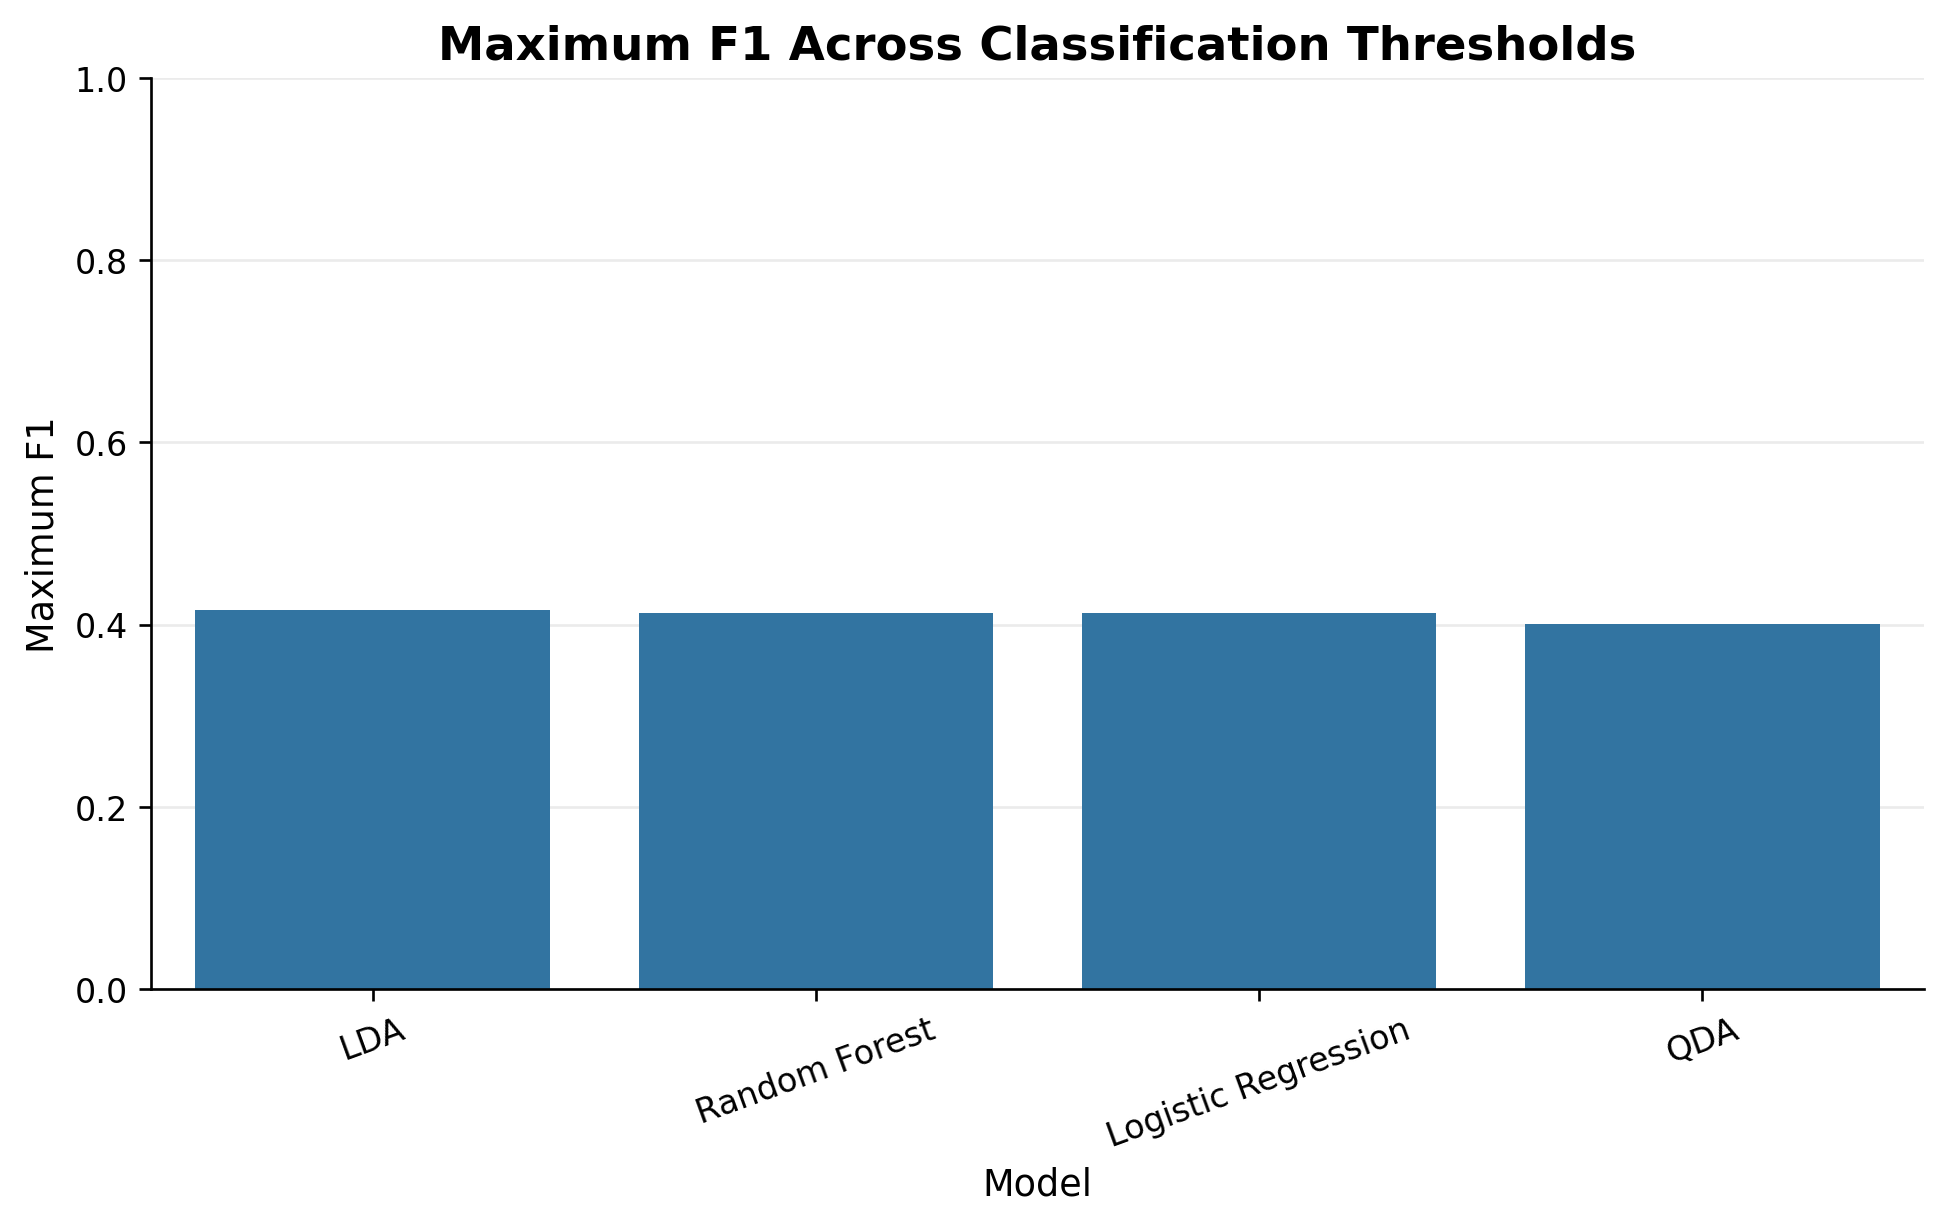

In [34]:
best_f1 = (
    threshold_results_df
    .groupby('Model')['F1']
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=best_f1,
    x='Model',
    y='F1'
)

plt.xlabel('Model')
plt.ylabel('Maximum F1')
plt.title('Maximum F1 Across Classification Thresholds')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

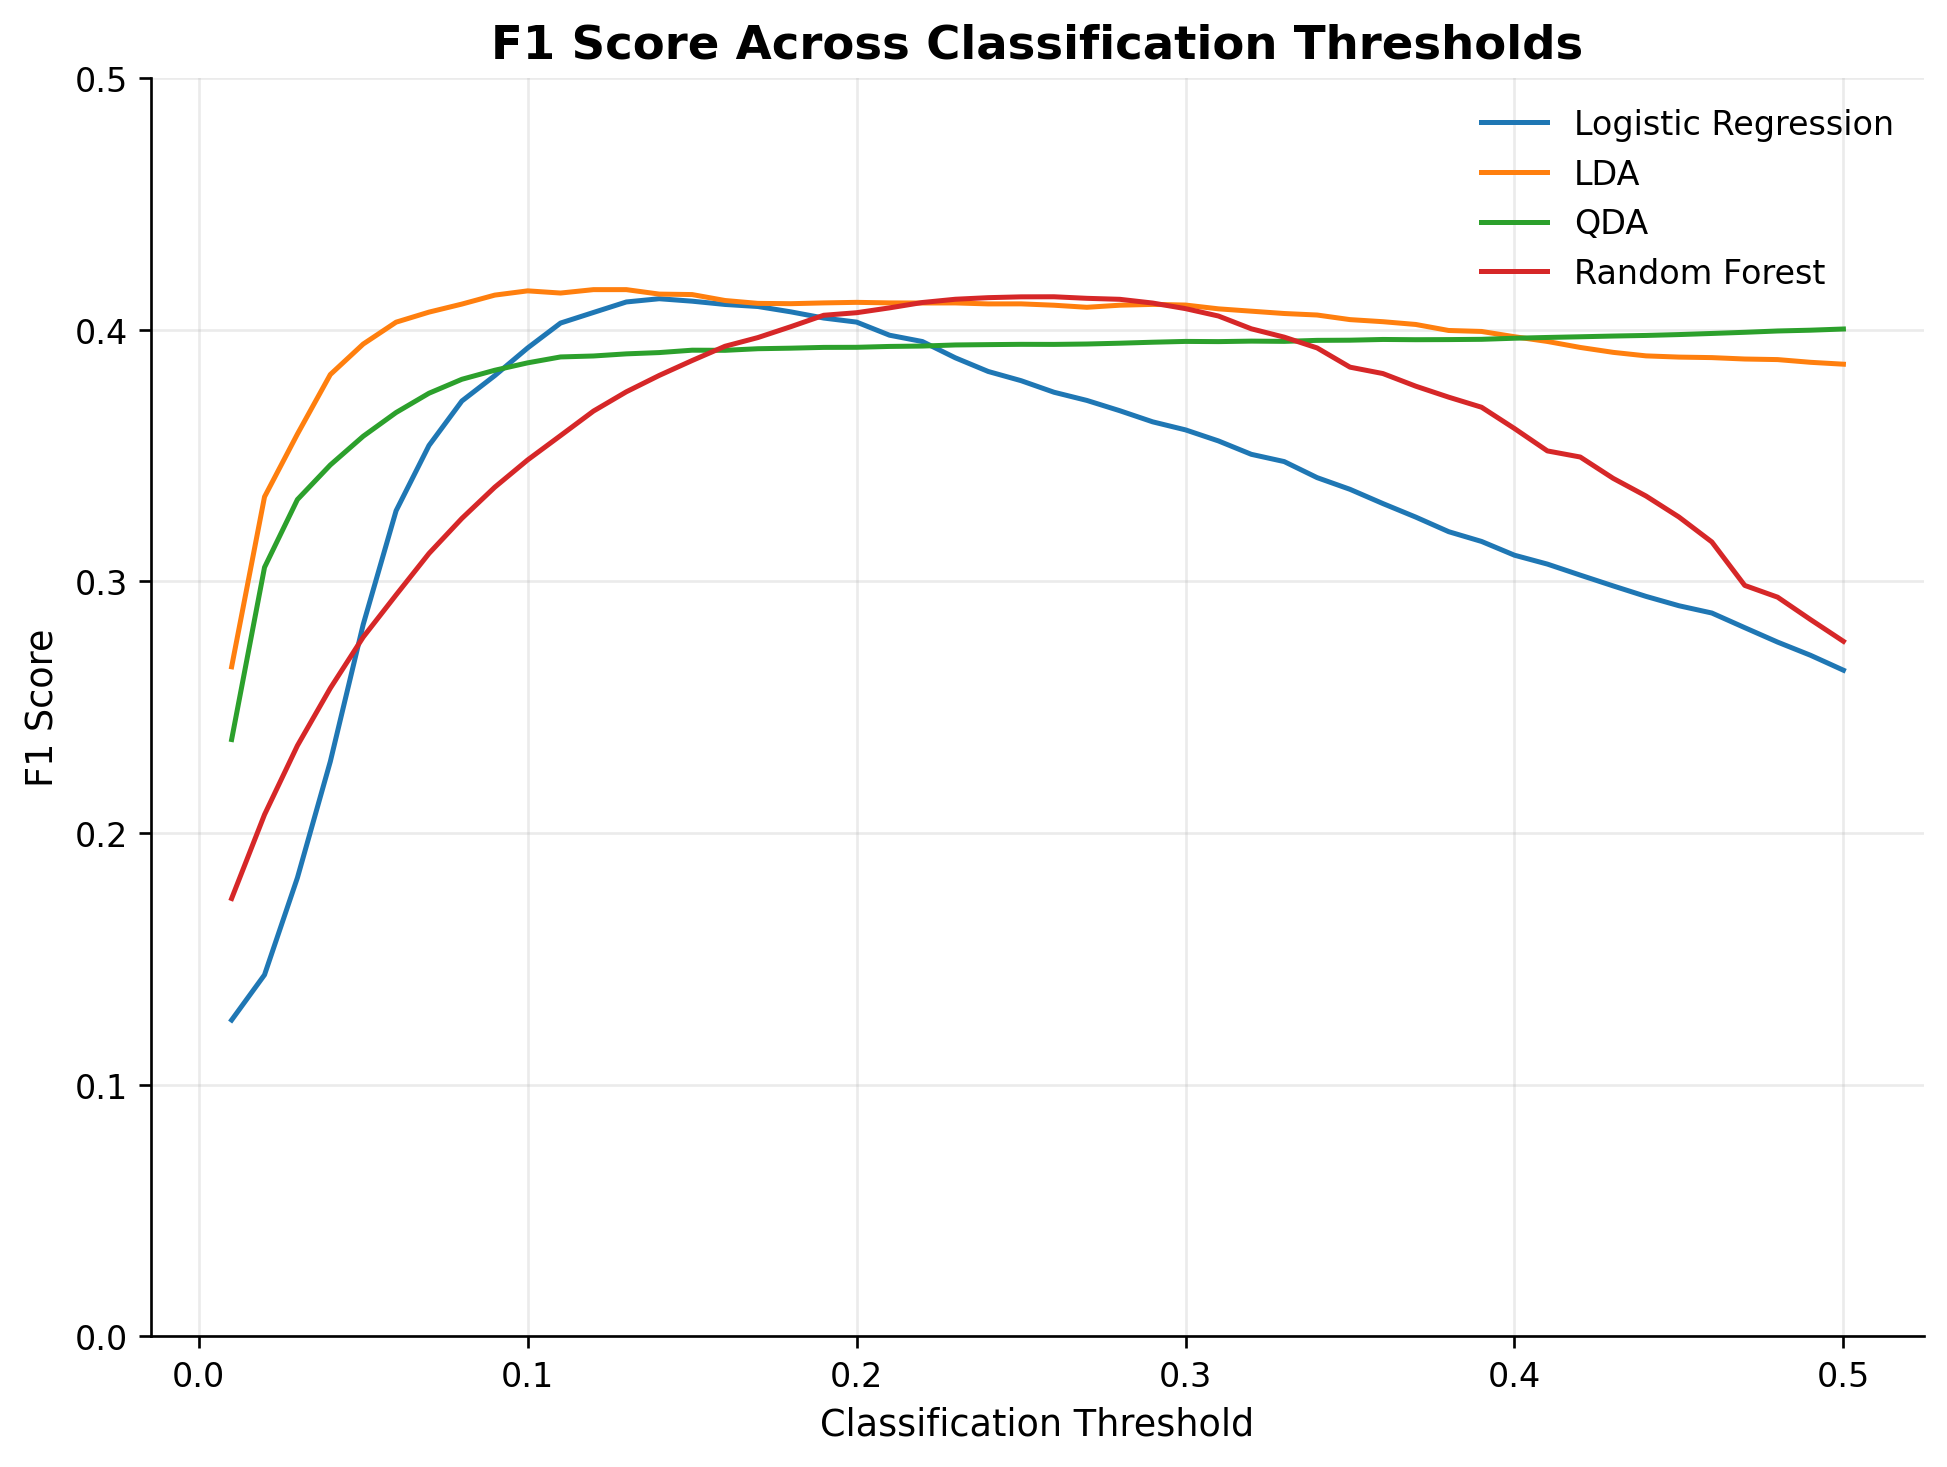

In [35]:
plt.figure(figsize=(8, 6))

for model_name in [
    'Logistic Regression',
    'LDA',
    'QDA',
    'Random Forest'
]:

    plot_data = threshold_results_df[
        threshold_results_df['Model'] == model_name
    ]

    sns.lineplot(
        data=plot_data,
        x='Threshold',
        y='F1',
        label=model_name
    )

plt.xlabel('Classification Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score Across Classification Thresholds')
plt.ylim(0, 0.5)
plt.legend()
plt.show()

##### 4.2.3.c Apply locked thresholds to test set

In [36]:
final_threshold_results = []

for model_name, model in threshold_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    selected_threshold = threshold_selection_df.loc[
        threshold_selection_df['Model'] == model_name,
        'Selected Threshold'
    ].iloc[0]

    for threshold_type, threshold in [
        ('Default (0.50)', 0.50),
        ('Selected (OOF)', selected_threshold)
    ]:

        y_pred = (y_prob >= threshold).astype(int)

        final_threshold_results.append({
            'Model': model_name,
            'Threshold Type': threshold_type,
            'Threshold': threshold,
            'Precision': precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            'Recall': recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            'F1': f1_score(
                y_test,
                y_pred,
                zero_division=0
            )
        })

final_threshold_results_df = (
    pd.DataFrame(final_threshold_results)
    .sort_values(['Model', 'Threshold Type'])
    .reset_index(drop=True)
    .round(3)
)

display(final_threshold_results_df)

,Model,Threshold Type,Threshold,Precision,Recall,F1
0,LDA,Default (0.50),0.50,0.446,0.324,0.375
1,LDA,Selected (OOF),0.12,0.369,0.485,0.419
2,Logistic Regression,Default (0.50),0.50,0.542,0.163,0.250
3,Logistic Regression,Selected (OOF),0.14,0.380,0.465,0.418
4,QDA,Default (0.50),0.50,0.326,0.529,0.404
5,QDA,Selected (OOF),0.50,0.326,0.529,0.404
6,Random Forest,Default (0.50),0.50,0.521,0.181,0.269
7,Random Forest,Selected (OOF),0.26,0.391,0.458,0.422


##### Interpretation

Lowering the threshold substantially increases recall for the three leading models, but at the cost of lower precision. The appropriate threshold would therefore depend on how many borrowers can realistically be flagged for further action.

## 5. Conclusion, Limitations

### 5.1 Conclusion

The models provide meaningful predictive information about serious delinquency. LDA achieves the highest ROC-AUC (0.851), closely followed by Random Forest (0.849) and Logistic Regression (0.839). The relatively small differences suggest that the additional complexity of Random Forest provides limited predictive improvement over simpler models.

Previous delinquency history, credit utilisation, income, and indebtedness are among the most informative predictors, although their relative importance varies across models.

The threshold analysis highlights an important distinction between ranking borrowers by risk and deciding who to flag. ROC-AUC measures the former, while the choice of threshold determines the latter. In practice, this threshold would depend on the costs of false positives and false negatives and the capacity available to act on flagged borrowers.

### 5.2 Limitations

- **No temporal validation**: The model was evaluated using a random train/test split rather than testing on borrowers from a later period. Performance may therefore differ when applied to future borrowers.
- **Limited outcome**: The target only captures serious delinquency within two years and does not capture the financial cost of different outcomes.
- **Threshold selection**: The threshold was chosen using F1 rather than an explicit business cost function. A real application would need to consider the costs of different types of errors.

In [37]:
test_data = pd.read_csv("../data/cs-test.csv", index_col=0)

In [38]:
test_data['Probability'] = models['LDA'].predict_proba(test_data)[:, 1]
test_data['Id'] = list(range(1, len(test_data) + 1))
test_data[['Id', 'Probability']].to_csv("../output/cs-test-submitted.csv", index=False)